# kNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import metrics

# Load the iris dataset
data = load_iris()
X = data.data
y = data.target

In [2]:
# Set up parameters for k-nearest neighbors model
param_grid = {'n_neighbors': np.arange(1, 11)}

# LOOCV method
loo = LeaveOneOut()
knn_loo = KNeighborsClassifier()

# Grid Search with LOOCV
model_loo = GridSearchCV(knn_loo, param_grid, cv = loo)
model_loo.fit(X, y)

GridSearchCV(cv=LeaveOneOut(), estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])})

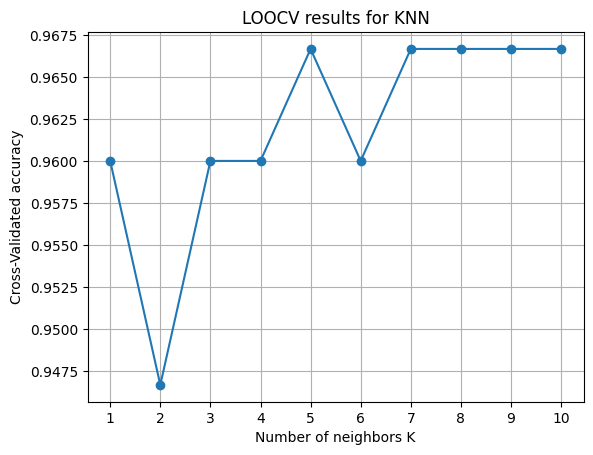

In [3]:
# Plotting the mean test scores for different values of k
plt.plot(range(1, 11), model_loo.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Number of neighbors K')
plt.ylabel('Cross-Validated accuracy')
plt.title('LOOCV results for KNN')
plt.xticks(np.arange(1, 11))
plt.grid(True)
plt.show()

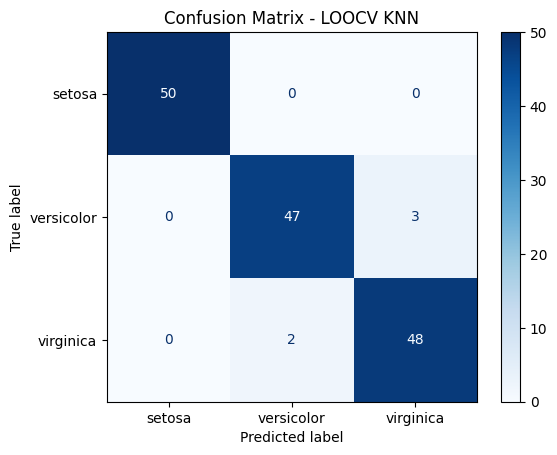

In [4]:
# Generate predictions and confusion matrix using the best model
y_pred = cross_val_predict(model_loo.best_estimator_, X, y, cv = loo)
cm = confusion_matrix(y, y_pred)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = data.target_names)
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion Matrix - LOOCV KNN')
plt.show()

In [5]:
print("Accuracy:", metrics.accuracy_score(y, y_pred))

Accuracy: 0.9666666666666667


# Decision tree

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [7]:
# Load the iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.DataFrame(data.target, columns = ['Species'])

# Combine features and target into a single DataFrame
iris_df = pd.concat([X, y], axis = 1)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
# Initialize the Leave-One-Out cross-validator
loo = LeaveOneOut()

# Create a decision tree classifier instance
tree_model = DecisionTreeClassifier(min_samples_leaf = 10)

# Fit the model to the entire dataset
tree_model.fit(X, y['Species'])

y_pred = tree_model.predict(X)

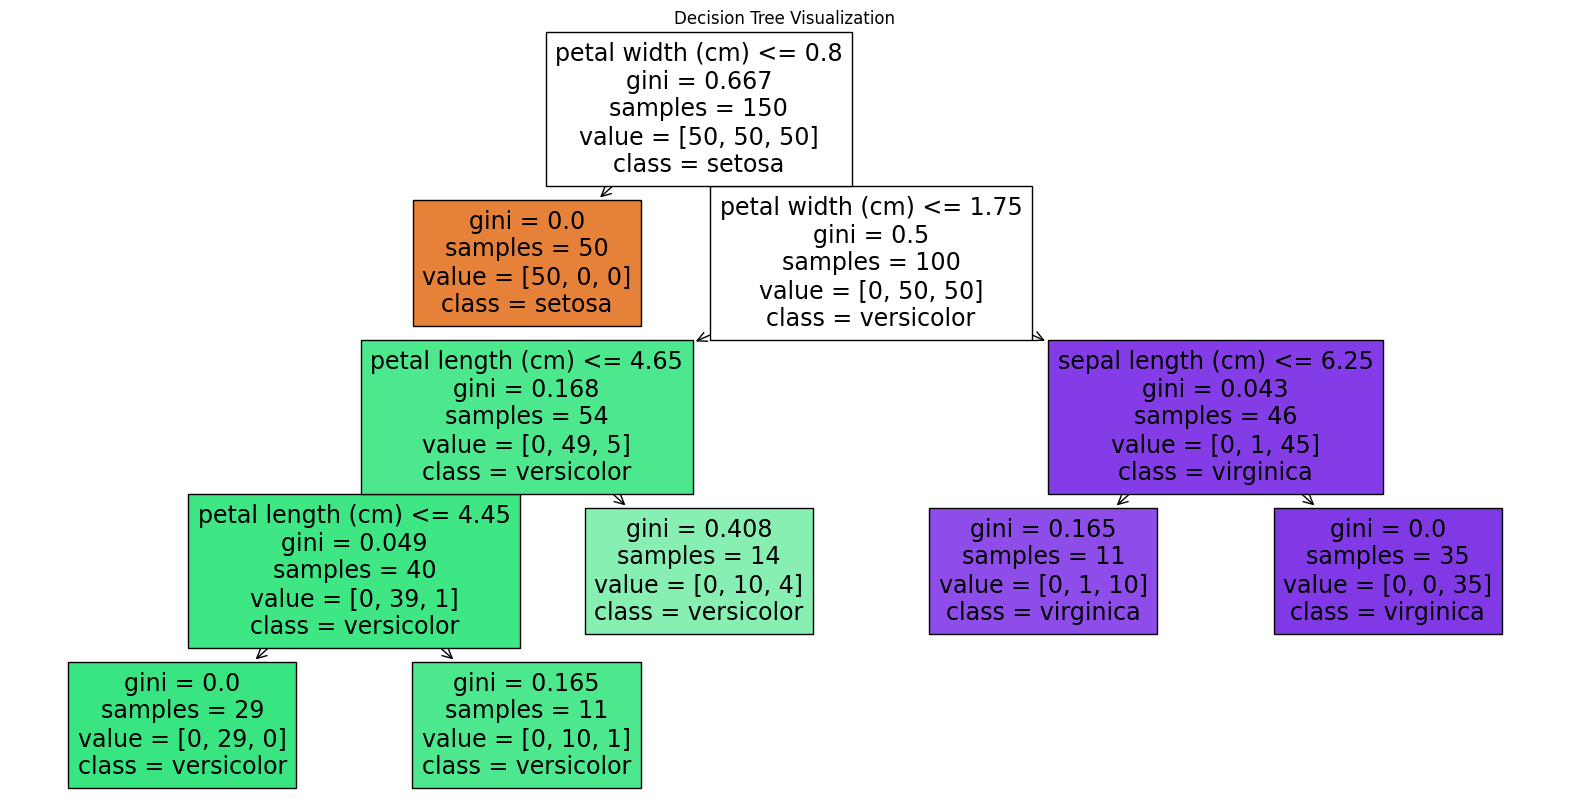

In [9]:
# Plotting the tree
plt.figure(figsize = (20, 10))
plot_tree(tree_model,
          filled = True,
          feature_names = data.feature_names,
          class_names = data.target_names)
plt.title('Decision Tree Visualization')
plt.show()

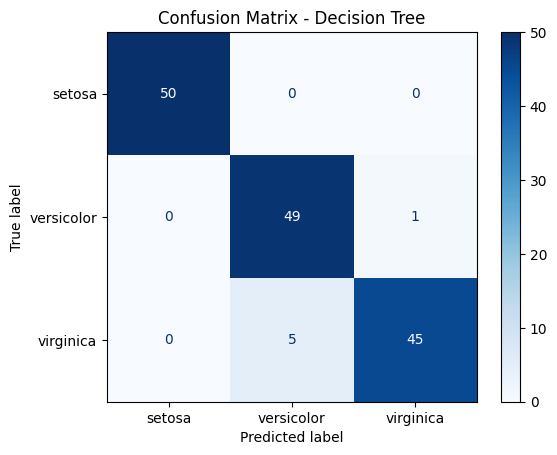

In [10]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = data.target_names)
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [11]:
print("Accuracy:", metrics.accuracy_score(y, y_pred))

Accuracy: 0.96


# Random forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Create a Random Forest classifier instance
random_forest = RandomForestClassifier(n_estimators = 100)

In [14]:
loo_scores = cross_val_score(random_forest, X, y['Species'], cv = loo)
print(f"Average LOOCV Score: {loo_scores.mean() * 100}")

Average LOOCV Score: 96.0


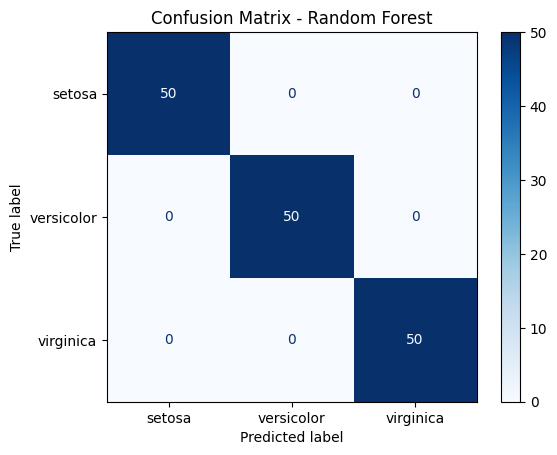

In [15]:
# Fit the model to the entire dataset for evaluation
random_forest.fit(X, y['Species'])

# Generate predictions for the entire dataset (normally you'd use a test set)
y_pred = random_forest.predict(X)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Neural net

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


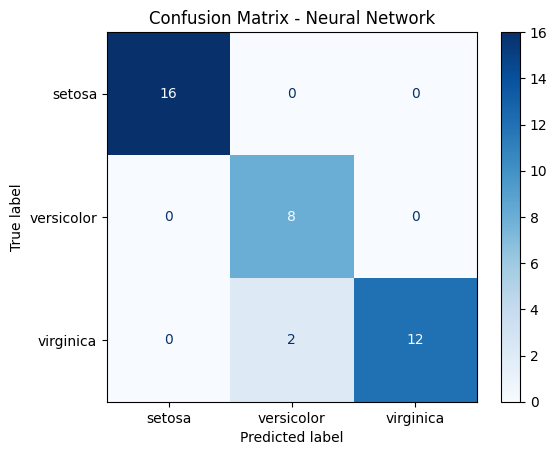

In [17]:
# Normalize input data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.25)

# Train a neural network
mlp = MLPClassifier(hidden_layer_sizes = 10, max_iter = 1000)
mlp.fit(X_train, y_train)

# Prediction and evaluate the model
y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Neural Network')
plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.80      1.00      0.89         8
           2       1.00      0.86      0.92        14

    accuracy                           0.95        38
   macro avg       0.93      0.95      0.94        38
weighted avg       0.96      0.95      0.95        38



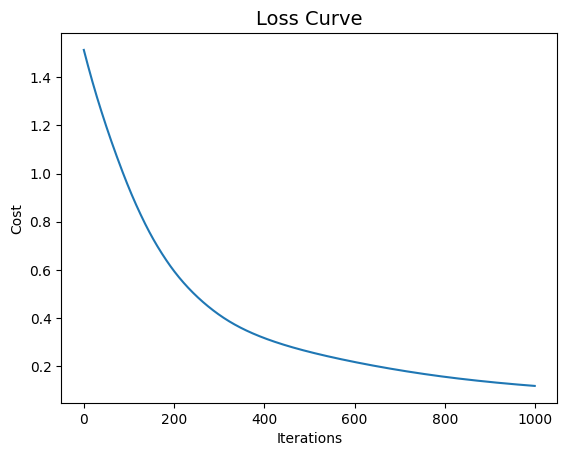

In [19]:
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve", fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

# Support Vector Machines (SVM)

In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

In [21]:
# Set up the SVM with a radial basis function kernel
# Preprocessing and model in a pipeline
svm_pipeline = make_pipeline(StandardScaler(),
                             SVC(kernel = 'rbf'))

# Grid search parameters
param_grid = {
    'svc__C': [0.25, 0.5, 1],
    'svc__gamma': np.arange(0.1, 0.6, 0.1)  # gamma is 1/(2*sigma^2) in sklearn, sigma = seq(0.1, 0.5, by = 0.1)
}

# Set up GridSearchCV
grid_search = GridSearchCV(svm_pipeline, param_grid, cv = 5, verbose = 1)

In [22]:
# Fit model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits


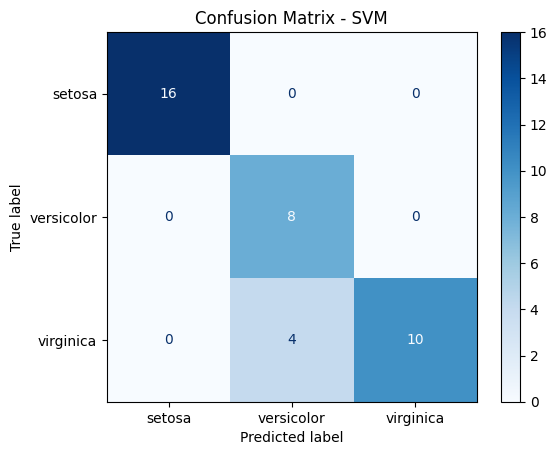

In [23]:
# Make predictions
y_pred = best_model.predict(X_test)

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix,
                              display_labels = data.target_names)
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion Matrix - SVM')
plt.show()

# Exercice 1 (20 minutes)

For the data: [https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data](https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data) (heart diseases in South Africa), calculate the resubstitution error and the 10-fold cross-validation (10CV) error for the 3-NN and RF (Random Forest) methods. For the Random Forest model, display the confusion matrix and interpret it. Which model would you recommend for this problem?